# Notebook 01 - Sức khỏe doanh thu

**Mục tiêu:** phân tích xu hướng `Revenue`, `COGS`, biên lợi nhuận gộp, mùa vụ, ngày bất thường và các động lực cấp đơn hàng. Notebook này phục vụ câu hỏi: doanh thu tăng nhờ khối lượng đơn, giá trị đơn hàng, khuyến mãi hay mùa vụ?

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
for candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (candidate / "datathon-2026-round-1").exists():
        PROJECT_ROOT = candidate
        break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

from EDA.constants.config import FIGURES_DIR, WEEKDAY_ORDER, AGE_ORDER, SIZE_ORDER
from EDA.utils.io import load_tables, build_order_metrics, build_order_item_metrics
from EDA.utils.plotting import setup_vietnamese_style, save_figure, format_money_axis, format_percent_axis, money_formatter
from EDA.utils.validation import quality_report, foreign_key_report

setup_vietnamese_style()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Tải dữ liệu và kiểm tra chất lượng

In [2]:
tables = load_tables(["sales", "orders", "order_items", "payments"])
sales, orders, items, payments = tables["sales"], tables["orders"], tables["order_items"], tables["payments"]
display(quality_report(tables))
display(pd.DataFrame([
    foreign_key_report(items, orders, "order_id", "order_id", "order_items", "orders"),
    foreign_key_report(payments, orders, "order_id", "order_id", "payments", "orders"),
]))
display(Markdown(f"**Insight ngắn:** dữ liệu có {len(sales):,} ngày doanh thu từ {sales.Date.min().date()} đến {sales.Date.max().date()}, {orders.order_id.nunique():,} đơn hàng và quan hệ khóa chính hợp lệ."))

,bảng,số dòng,số cột,ô thiếu,dòng trùng,dung lượng MB
2,order_items,714669,7,1152816,0,80.1100
1,orders,646945,8,0,0,182.5200
3,payments,646945,4,0,0,55.5000
0,sales,3833,3,0,0,0.0900


,quan hệ,số khóa thiếu,tỷ lệ dòng bị ảnh hưởng,hợp lệ
0,order_items.order_id → orders.order_id,0,0.0000,True
1,payments.order_id → orders.order_id,0,0.0000,True


**Insight ngắn:** dữ liệu có 3,833 ngày doanh thu từ 2012-07-04 đến 2022-12-31, 646,945 đơn hàng và quan hệ khóa chính hợp lệ.

## 2. Xu hướng doanh thu, COGS và biên lợi nhuận

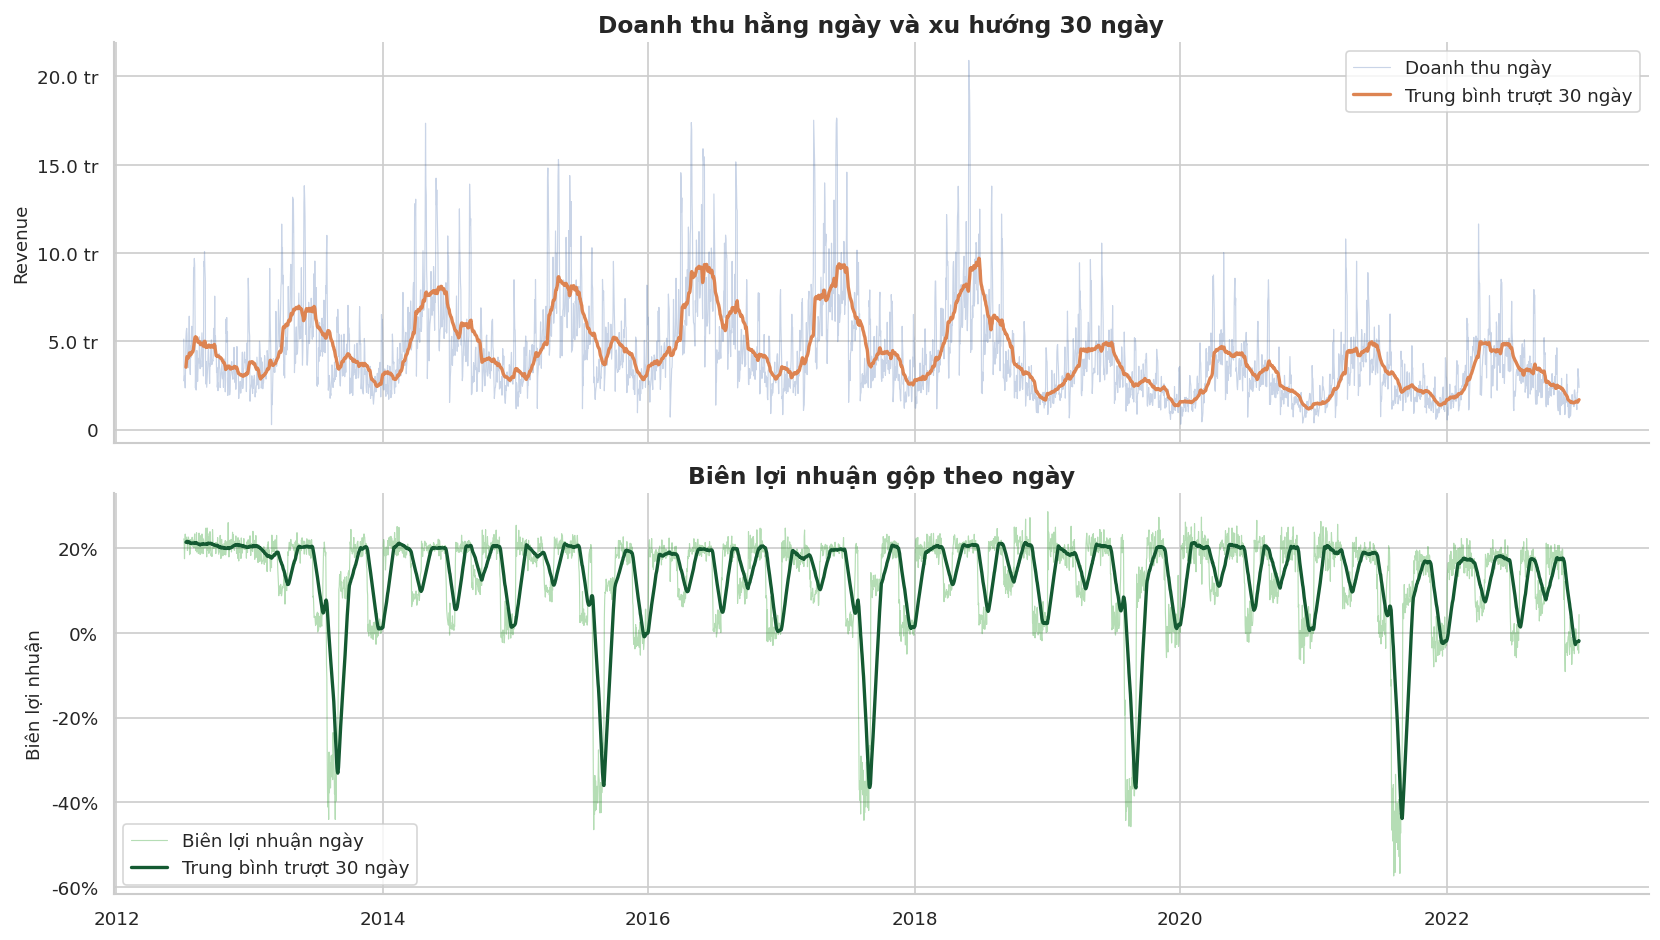

,Revenue,COGS,gross_profit,gross_margin,revenue_yoy
year,,,,,
2015,"1,889,933,827","1,665,441,817","224,492,010",11.88%,0.97%
2016,"2,104,640,678","1,780,559,393","324,081,285",15.40%,11.36%
2017,"1,911,164,325","1,694,385,794","216,778,532",11.34%,-9.19%
2018,"1,850,122,456","1,542,175,766","307,946,690",16.64%,-3.19%
2019,"1,136,801,442","1,005,202,884","131,598,558",11.58%,-38.56%
2020,"1,054,512,159","886,085,098","168,427,061",15.97%,-7.24%
2021,"1,043,039,820","941,130,120","101,909,699",9.77%,-1.09%
2022,"1,169,748,832","1,020,420,164","149,328,668",12.77%,12.15%


**Insight ngắn:** tổng doanh thu đạt 16.4 tỷ, biên lợi nhuận gộp trung bình 13.80%; năm doanh thu cao nhất là 2016.

In [3]:
s = sales.sort_values("Date").copy()
s["gross_profit"] = s["Revenue"] - s["COGS"]
s["gross_margin"] = s["gross_profit"] / s["Revenue"]
s["year"] = s["Date"].dt.year
s["month"] = s["Date"].dt.month
s["weekday"] = s["Date"].dt.weekday.map(dict(enumerate(WEEKDAY_ORDER)))
annual = s.groupby("year").agg(Revenue=("Revenue", "sum"), COGS=("COGS", "sum"), gross_profit=("gross_profit", "sum"))
annual["gross_margin"] = annual["gross_profit"] / annual["Revenue"]
annual["revenue_yoy"] = annual["Revenue"].pct_change()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(s.Date, s.Revenue, alpha=.3, linewidth=.7, label="Doanh thu ngày")
axes[0].plot(s.Date, s.Revenue.rolling(30, min_periods=7).mean(), linewidth=2, label="Trung bình trượt 30 ngày")
axes[0].set_title("Doanh thu hằng ngày và xu hướng 30 ngày"); axes[0].set_ylabel("Revenue"); format_money_axis(axes[0]); axes[0].legend()
axes[1].plot(s.Date, s.gross_margin, alpha=.35, linewidth=.7, color="#2ca02c", label="Biên lợi nhuận ngày")
axes[1].plot(s.Date, s.gross_margin.rolling(30, min_periods=7).mean(), linewidth=2, color="#145a32", label="Trung bình trượt 30 ngày")
axes[1].set_title("Biên lợi nhuận gộp theo ngày"); axes[1].set_ylabel("Biên lợi nhuận"); format_percent_axis(axes[1]); axes[1].legend()
save_figure("01_revenue_health_timeseries", fig); plt.show()

display(annual.tail(8).style.format({"Revenue": "{:,.0f}", "COGS": "{:,.0f}", "gross_profit": "{:,.0f}", "gross_margin": "{:.2%}", "revenue_yoy": "{:.2%}"}))
total_revenue = s.Revenue.sum()
overall_margin = s.gross_profit.sum() / total_revenue
best_year = int(annual.loc[annual.index >= 2013, "Revenue"].idxmax())
display(Markdown(f"**Insight ngắn:** tổng doanh thu đạt {money_formatter(total_revenue)}, biên lợi nhuận gộp trung bình {overall_margin:.2%}; năm doanh thu cao nhất là {best_year}."))

## 3. Mùa vụ và ngày bất thường

C:\Users\ACER\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


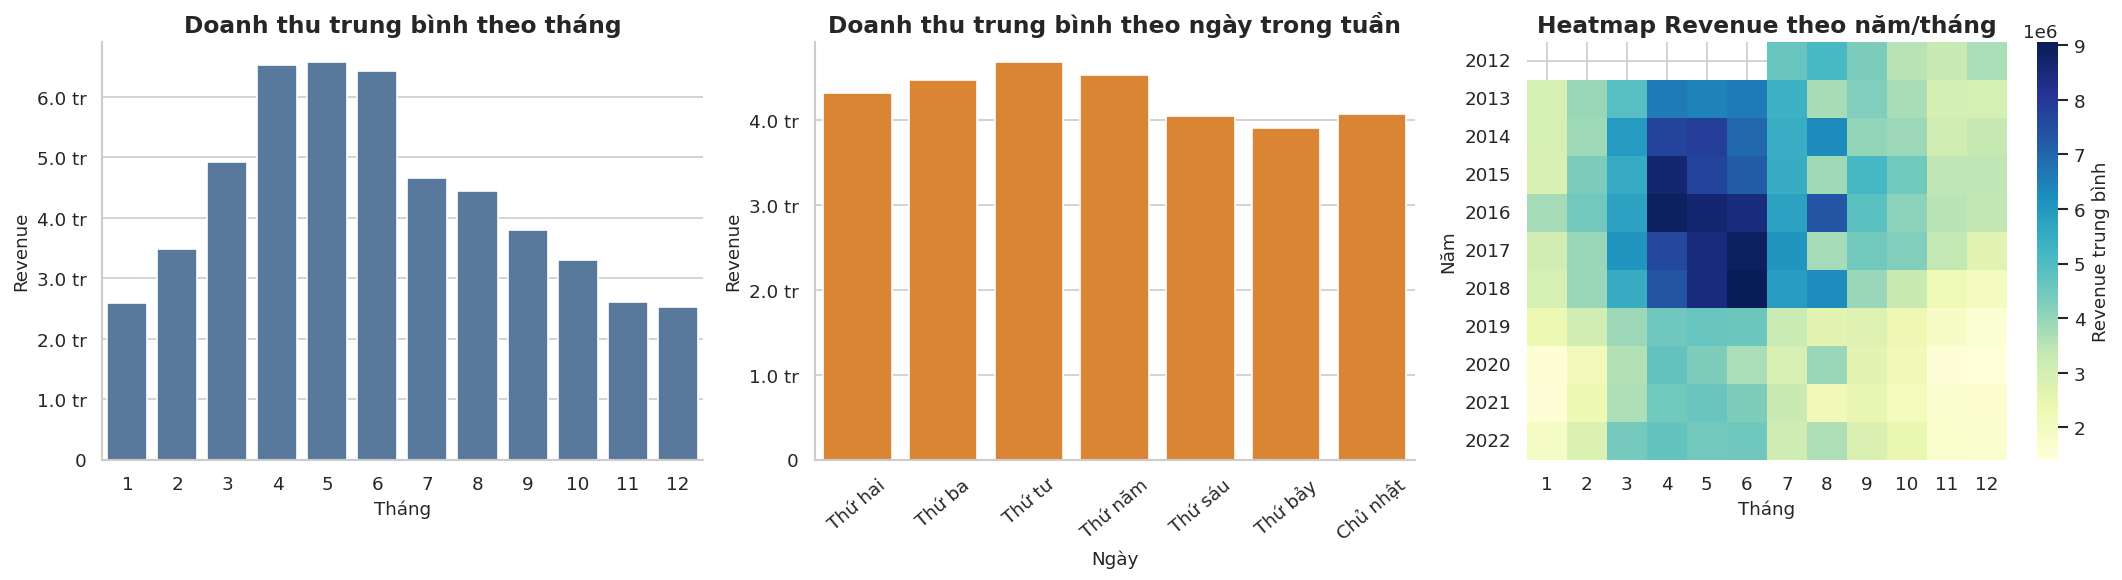

,Date,Revenue,expected,residual
2156,2018-05-30 00:00:00,"20,905,271","7,830,057","13,075,214"
2158,2018-06-01 00:00:00,"19,245,166","7,388,259","11,856,907"
2157,2018-05-31 00:00:00,"19,289,944","7,625,783","11,664,161"
1730,2017-03-30 00:00:00,"17,516,039","6,398,148","11,117,890"
664,2014-04-29 00:00:00,"17,347,427","6,883,744","10,463,683"
1731,2017-03-31 00:00:00,"16,556,662","6,370,796","10,185,866"
2159,2018-06-02 00:00:00,"17,529,108","7,388,259","10,140,850"
1793,2017-06-01 00:00:00,"17,639,271","7,812,749","9,826,522"
1516,2016-08-28 00:00:00,"15,158,669","5,350,595","9,808,074"
1794,2017-06-02 00:00:00,"17,528,853","7,812,749","9,716,104"


**Insight ngắn:** tháng 5 là tháng có doanh thu trung bình cao nhất; các ngày outlier nên được gắn cờ khi phân tích campaign hoặc xây mô hình dự báo.

In [4]:
monthly = s.groupby("month", as_index=False).agg(avg_revenue=("Revenue", "mean"), avg_margin=("gross_margin", "mean"))
weekday = s.groupby("weekday", as_index=False).agg(avg_revenue=("Revenue", "mean"))
weekday["weekday"] = pd.Categorical(weekday["weekday"], WEEKDAY_ORDER, ordered=True)
weekday = weekday.sort_values("weekday")
heat = s.groupby(["year", "month"])["Revenue"].mean().unstack("month").reindex(columns=range(1, 13))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=monthly, x="month", y="avg_revenue", color="#4c78a8", ax=axes[0])
axes[0].set_title("Doanh thu trung bình theo tháng"); axes[0].set_xlabel("Tháng"); axes[0].set_ylabel("Revenue"); format_money_axis(axes[0])
sns.barplot(data=weekday, x="weekday", y="avg_revenue", color="#f58518", ax=axes[1])
axes[1].set_title("Doanh thu trung bình theo ngày trong tuần"); axes[1].set_xlabel("Ngày"); axes[1].set_ylabel("Revenue"); axes[1].tick_params(axis="x", rotation=40); format_money_axis(axes[1])
sns.heatmap(heat, cmap="YlGnBu", ax=axes[2], cbar_kws={"label": "Revenue trung bình"})
axes[2].set_title("Heatmap Revenue theo năm/tháng"); axes[2].set_xlabel("Tháng"); axes[2].set_ylabel("Năm")
save_figure("01_revenue_health_seasonality", fig); plt.show()

baseline = s.Revenue.rolling(30, min_periods=14, center=True).median()
anomalies = s.assign(expected=baseline, residual=s.Revenue - baseline).dropna()
anomalies["abs_z"] = (anomalies.residual / anomalies.residual.std()).abs()
anomalies = anomalies.sort_values("abs_z", ascending=False).head(10)
display(anomalies[["Date", "Revenue", "expected", "residual"]].style.format({"Revenue": "{:,.0f}", "expected": "{:,.0f}", "residual": "{:,.0f}"}))
peak_month = int(monthly.loc[monthly.avg_revenue.idxmax(), "month"])
display(Markdown(f"**Insight ngắn:** tháng {peak_month} là tháng có doanh thu trung bình cao nhất; các ngày outlier nên được gắn cờ khi phân tích campaign hoặc xây mô hình dự báo."))

## 4. Động lực cấp đơn hàng

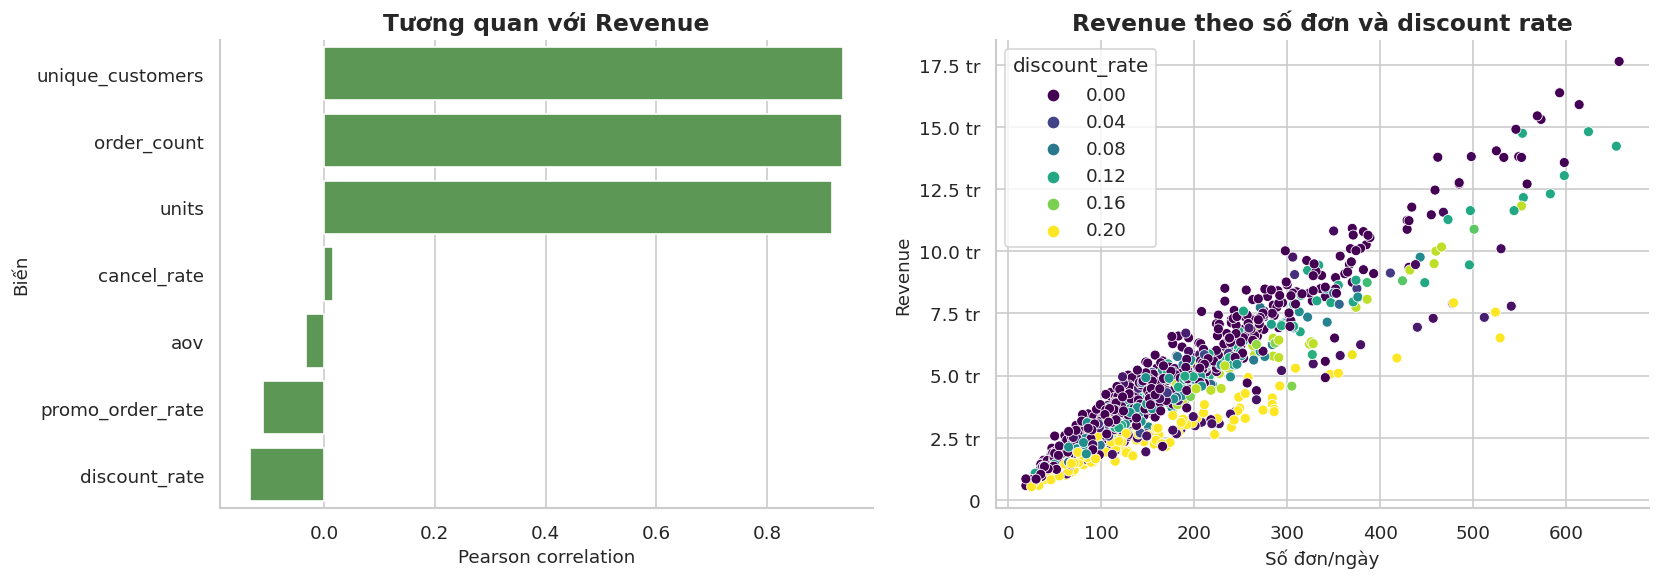

,corr_with_revenue
unique_customers,0.937
order_count,0.936
units,0.918
cancel_rate,0.015
aov,-0.032
promo_order_rate,-0.111
discount_rate,-0.134


**Kết luận chung:** Revenue chịu tác động đồng thời bởi mùa vụ, số đơn, số khách, số lượng bán, AOV và khuyến mãi. Biên lợi nhuận toàn kỳ khoảng 13.80%, nên mọi khuyến nghị tăng trưởng cần kiểm tra thêm COGS/margin thay vì chỉ nhìn doanh thu.

In [5]:
order_metrics = build_order_metrics(items)
fact = orders.merge(order_metrics, on="order_id", how="left")
daily_orders = fact.groupby("order_date", as_index=False).agg(
    order_count=("order_id", "nunique"), unique_customers=("customer_id", "nunique"),
    net_sales=("net_sales", "sum"), gross_sales=("gross_sales", "sum"),
    discount_amount=("discount_amount", "sum"), units=("units", "sum"),
    promo_orders=("has_promo", "sum"), cancelled=("order_status", lambda x: (x == "cancelled").sum())
)
daily_orders["aov"] = daily_orders.net_sales / daily_orders.order_count
daily_orders["discount_rate"] = daily_orders.discount_amount / daily_orders.gross_sales.replace(0, pd.NA)
daily_orders["promo_order_rate"] = daily_orders.promo_orders / daily_orders.order_count
daily_orders["cancel_rate"] = daily_orders.cancelled / daily_orders.order_count
daily = s.merge(daily_orders, left_on="Date", right_on="order_date", how="left")
corr = daily[["Revenue", "order_count", "unique_customers", "units", "aov", "discount_rate", "promo_order_rate", "cancel_rate"]].corr(numeric_only=True)["Revenue"].drop("Revenue").sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=corr.values, y=corr.index, color="#54a24b", ax=axes[0])
axes[0].set_title("Tương quan với Revenue"); axes[0].set_xlabel("Pearson correlation"); axes[0].set_ylabel("Biến")
sns.scatterplot(data=daily.sample(min(len(daily), 1200), random_state=2026), x="order_count", y="Revenue", hue="discount_rate", palette="viridis", ax=axes[1])
axes[1].set_title("Revenue theo số đơn và discount rate"); axes[1].set_xlabel("Số đơn/ngày"); axes[1].set_ylabel("Revenue"); format_money_axis(axes[1])
save_figure("01_revenue_health_order_drivers", fig); plt.show()
display(corr.to_frame("corr_with_revenue").style.format("{:.3f}"))
display(Markdown(f"**Kết luận chung:** Revenue chịu tác động đồng thời bởi mùa vụ, số đơn, số khách, số lượng bán, AOV và khuyến mãi. Biên lợi nhuận toàn kỳ khoảng {overall_margin:.2%}, nên mọi khuyến nghị tăng trưởng cần kiểm tra thêm COGS/margin thay vì chỉ nhìn doanh thu."))